/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fi

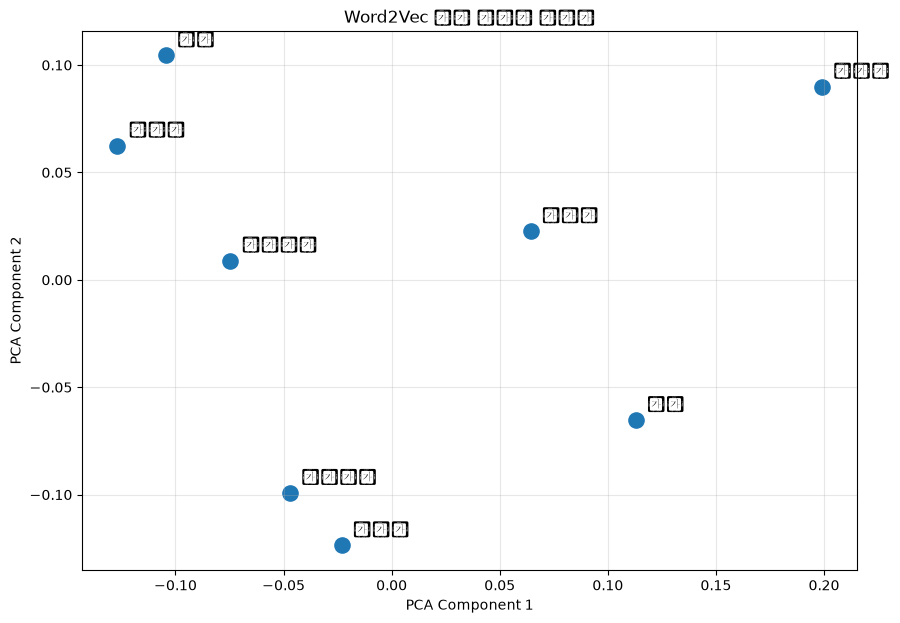

=== 단어 목록 ===
['나는', '먹었다', '좋아한다', '철수는', '바나나', '사과', '자동차', '운전한다']

=== 사과와 비슷한 단어 ===
[('바나나', 0.2515230178833008), ('철수는', 0.0920533686876297), ('운전한다', -0.020844751968979836), ('자동차', -0.03658043220639229), ('좋아한다', -0.14868101477622986), ('나는', -0.2674509882926941), ('먹었다', -0.37925004959106445)]

=== 바나나와 비슷한 단어 ===
[('자동차', 0.6174455285072327), ('사과', 0.2515230178833008), ('나는', -0.21735161542892456), ('운전한다', -0.28691011667251587), ('좋아한다', -0.3183988630771637), ('철수는', -0.360983669757843), ('먹었다', -0.5369502305984497)]

=== 사과 vs 바나나 ===
0.25152302


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import Word2Vec

sentences = [
    ["나는", "사과", "먹었다"],
    ["나는", "바나나", "먹었다"],
    ["철수는", "사과", "먹었다"],
    ["철수는", "바나나", "먹었다"],
    ["나는", "사과", "좋아한다"],
    ["나는", "바나나", "좋아한다"],
    ["철수는", "자동차", "좋아한다"],
    ["나는", "자동차", "운전한다"],
]

model = Word2Vec(
    sentences=sentences, vector_size=10, window=2, min_count=1, sg=0, epochs=200
)

words = model.wv.index_to_key
vectors = np.array([model.wv[word] for word in words])

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(10, 7))

plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], s=120)

for i, word in enumerate(words):
    plt.annotate(
        word,
        (vectors_2d[i, 0], vectors_2d[i, 1]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=12,
    )

plt.title("Word2Vec 단어 임베딩 시각화")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(alpha=0.3)
plt.show()

# 6. 단어 간 유사도도 확인
print("=== 단어 목록 ===")
print(words)

print("\n=== 사과와 비슷한 단어 ===")
print(model.wv.most_similar("사과"))

print("\n=== 바나나와 비슷한 단어 ===")
print(model.wv.most_similar("바나나"))

print("\n=== 사과 vs 바나나 ===")
print(model.wv.similarity("사과", "바나나"))
